# Лабораторная работа 3. Оптимизация, регуляризация и робастность нейросети
# Стрельченко Алексей Александрович
## Цель работы
Экспериментально проверить, как выбор оптимизатора и методов регуляризации влияет на сходимость, переобучение, обобщение и чувствительность модели к возмущениям входа.

## 0. Подготовка окружения

In [15]:
import sys
!{sys.executable} -m pip install torch --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [16]:
!{sys.executable} -m pip install torchvision

In [17]:
# TODO: импортируйте необходимые библиотеки
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cpu


## 1. Данные

**Задание:** загрузите датасет для классификации изображений.
Рекомендуется MNIST или Fashion-MNIST (через `torchvision.datasets`).


In [18]:
# Датасет: MNIST

#склеивает несколько преобразований в одно.
transform = transforms.Compose([transforms.ToTensor()])
#transforms.ToTensor() - превращает картинку в тензор.
#тензор формы [1, 28, 28], значения 0.0–1.0 (1 канал для ЧБ)

full_train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Разделение train/val/test
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [55000, 5000],
    generator=torch.Generator().manual_seed(RANDOM_STATE)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=50, shuffle=False)

## 2. Формализм прямого прохода и backpropagation

**Задание:** опишите (в markdown, формулами) прямой проход для вашей архитектуры и кратко распишите, как вычисляется ошибка слоя \( \delta^{(l)} \) через цепное правило.

**Вопрос для отчёта:** почему backpropagation имеет вычислительную сложность \(O(P)\) по числу параметров, а не \(O(2P)\), как при наивном численном дифференцировании?


## Формализм прямого прохода и backpropagation

### Обозначения

- $x$ — вход, картинка 28×28 развёрнутая в вектор длины 784
- $W^{(1)}, W^{(2)}, W^{(3)}$ — матрицы весов слоёв
- $b^{(1)}, b^{(2)}, b^{(3)}$ — сдвиги
- 10 — число классов (цифры 0–9)

### Прямой проход

Данные идут через первый скрытый слой:

$$z^{(1)} = xW^{(1)} + b^{(1)}$$

$$a^{(1)} = \text{ReLU}(z^{(1)})$$

ReLU нужна чтобы добавить нелинейность — без неё вся сеть схлопнется в одну линейную модель.

Потом второй скрытый слой:

$$z^{(2)} = a^{(1)}W^{(2)} + b^{(2)}$$

$$a^{(2)} = \text{ReLU}(z^{(2)})$$

И выходной слой:

$$z^{(3)} = a^{(2)}W^{(3)} + b^{(3)}$$

На выходе получаем 10 чисел (логитов). Чтобы превратить их в вероятности — применяем softmax:

$$\hat{p}_k = \frac{\exp(z^{(3)}_k)}{\sum_{j=1}^{10} \exp(z^{(3)}_j)}$$

Теперь $\hat{p}$ — это вектор вероятностей, сумма = 1.

### Функция потерь

Использую кросс-энтропию:

$$L = -\sum_{k=1}^{10} y_k \log \hat{p}_k$$

где $y$ — правильный класс, записанный в виде вектора из нулей и одной единицы. По сути остаётся только $-\log \hat{p}$ для правильного класса — чем увереннее и правильнее предсказание, тем меньше loss.

### Ошибка слоя δ

Обозначим ошибку слоя как:

$$\delta^{(l)} = \frac{\partial L}{\partial z^{(l)}}$$

Для выходного слоя при связке softmax + кросс-энтропия получается очень удобный результат:

$$\delta^{(3)} = \hat{p} - y$$

Это не совпадение, а следствие того, что производные softmax и кросс-энтропии при взятии цепного правила сокращаются. Если кратко:

- производная кросс-энтропии по вероятности: $-\frac{y_k}{\hat{p}_k}$
- производная softmax по логиту: даёт два слагаемых (для совпадающего класса и для остальных)
- при подстановке в цепное правило лишние члены сокращаются, и остаётся простая разность $\hat{p}_k - y_k$

То есть ошибка выходного слоя — это просто разница между предсказанием и истиной. Например: если правильный класс — цифра 3, а модель дала вероятность 0.6, то для этого класса ошибка будет $0.6 - 1 = -0.4$, то есть надо увеличить логит этого класса.

Дальше идём назад по цепному правилу:

$$\delta^{(l)} = \left( (W^{(l+1)})^T \delta^{(l+1)} \right) \odot f'(z^{(l)})$$

где $\odot$ — поэлементное умножение, $f'$ — производная активации (для ReLU это 1 если $z>0$, иначе 0).

Для моей сети:

$$\delta^{(2)} = \left( (W^{(3)})^T \delta^{(3)} \right) \odot \text{ReLU}'(z^{(2)})$$

$$\delta^{(1)} = \left( (W^{(2)})^T \delta^{(2)} \right) \odot \text{ReLU}'(z^{(1)})$$

Смысл такой: ошибка выходного слоя "распространяется" назад через веса, а производная активации решает, пройдёт ли ошибка дальше (если нейрон был выключен ReLU — ошибка через него не идёт).

### Градиенты

Когда знаем δ, градиенты по весам и сдвигам получаются просто:

$$\frac{\partial L}{\partial W^{(l)}} = (a^{(l-1)})^T \delta^{(l)}$$

$$\frac{\partial L}{\partial b^{(l)}} = \delta^{(l)}$$

где $a^{(0)} = x$.

### Почему сложность O(P), а не O(2P)?

P — это общее число параметров сети (все веса и сдвиги).

#### Наивный метод

Чтобы найти градиент по каждому параметру, надо чуть изменить его и посмотреть, как изменится ошибка. На практике для этого делают два прямых прохода — с параметром +ε и с параметром −ε. Таких параметров P, и для каждого нужно два прохода. Один проход стоит O(P). Итого получается O(P²) — очень долго.

#### Backpropagation

Я не трогаю параметры, а считаю производные аналитически через цепное правило. Делаю один прямой проход и запоминаю промежуточные значения (z и a). Потом один обратный проход — и сразу получаю градиенты для всех параметров. Ошибка δ для слоя считается один раз и используется для всего слоя.

Итого: один прямой + один обратный проход, каждый O(P). Сложность O(P).


### Как находятся частные производные для градиентов

Выше я писал, что градиенты по весам и сдвигам получаются «просто»:

$$\frac{\partial L}{\partial W^{(l)}} = (a^{(l-1)})^T \delta^{(l)}$$

$$\frac{\partial L}{\partial b^{(l)}} = \delta^{(l)}$$

Но откуда это берётся? Разберу через цепное правило.

#### Градиент по сдвигу $b^{(l)}$

Вспомним прямой проход:

$$z^{(l)} = a^{(l-1)} W^{(l)} + b^{(l)}$$

Сдвиг $b^{(l)}$ прибавляется к $z^{(l)}$ напрямую. Значит:

$$\frac{\partial z^{(l)}}{\partial b^{(l)}} = 1$$

По цепному правилу:

$$\frac{\partial L}{\partial b^{(l)}} = \frac{\partial L}{\partial z^{(l)}} \cdot \frac{\partial z^{(l)}}{\partial b^{(l)}} = \delta^{(l)} \cdot 1 = \delta^{(l)}$$

То есть градиент по сдвигу — это **сама ошибка слоя**. Логично: сдвиг напрямую двигает $z$, поэтому его градиент равен ошибке.

#### Градиент по весу $W^{(l)}$

Тут сложнее, потому что $W$ — это матрица. Разберём **поэлементно**.

Пусть $W_{ij}$ — вес, который связывает $i$-й вход слоя с $j$-м нейроном. Тогда:

$$z_j = \sum_i a_i W_{ij} + b_j$$

Производная $z_j$ по $W_{ij}$:

$$\frac{\partial z_j}{\partial W_{ij}} = a_i$$

(потому что $W_{ij}$ умножается на $a_i$ в сумме, всё остальное — константы).

Для других $z_k$ ($k \neq j$) производная равна 0, потому что $W_{ij}$ не входит в них.

Теперь цепное правило для одного элемента $W_{ij}$:

$$\frac{\partial L}{\partial W_{ij}} = \sum_k \frac{\partial L}{\partial z_k} \cdot \frac{\partial z_k}{\partial W_{ij}}$$

Сумма по $k$ — потому что $W_{ij}$ может влиять на все выходы слоя. Но реально только $z_j$ зависит от $W_{ij}$, остальные дают 0. Остаётся:

$$\frac{\partial L}{\partial W_{ij}} = \delta_j \cdot a_i$$

То есть **градиент веса = вход × ошибка нейрона, к которому этот вес ведёт**.

#### Как собрать обратно в матрицу

Мы получили поэлементную формулу:

$$\frac{\partial L}{\partial W_{ij}} = a_i \cdot \delta_j$$

Чтобы записать её матрично, нужно **внешнее произведение** вектора $a$ и вектора $\delta$:

$$(a)^T \delta = \text{матрица, где элемент } (i, j) = a_i \cdot \delta_j$$

Именно для этого нужно **транспонирование** $a$: чтобы $a$ стал столбцом, а $\delta$ — строкой. Тогда их произведение даст матрицу нужного размера $[n, m]$, совпадающую с размером $W$.

Итого:

$$\frac{\partial L}{\partial W^{(l)}} = (a^{(l-1)})^T \delta^{(l)}$$

## 3. Базовая архитектура сети

In [19]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=784, hidden1=256, hidden2=128, hidden3=64, num_classes=10,
                 use_dropout=False, use_batchnorm=False, dropout_p=0.5):
        super().__init__()  # обязательный вызов конструктора родителя nn.Module

        # Первый блок: вход → скрытый слой 1
        layers = [
            nn.Flatten(),                    # картинка [batch, 1, 28, 28] → вектор [batch, 784]
            nn.Linear(input_dim, hidden1),   # полносвязный слой: 784 → 256
            nn.ReLU()                        # нелинейность: отрицательные → 0
        ]

        # Dropout перед BatchNorm — сначала случайно обнуляем нейроны, потом нормализуем оставшиеся
        if use_dropout:
            layers.append(nn.Dropout(dropout_p))

        # BatchNorm — нормализует активации, ускоряет обучение и стабилизирует
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden1))

        # Второй блок: скрытый слой 2
        layers += [
            nn.Linear(hidden1, hidden2),     # 256 → 128
            nn.ReLU()
        ]

        if use_dropout:
            layers.append(nn.Dropout(dropout_p))

        if use_batchnorm:
            layers.append(nn.BatchNorm1d(hidden2))

        # Третий блок: скрытый слой 3
        layers += [
            nn.Linear(hidden2, hidden3),     # 128 → 64
            nn.ReLU()
        ]

        if use_dropout:
            layers.append(nn.Dropout(dropout_p))

        # Выходной слой: 64 → 10 классов
        # Без ReLU и softmax — softmax добавит CrossEntropyLoss сам внутри
        layers.append(nn.Linear(hidden3, num_classes))

        # Собираем все слои в одну последовательную сеть
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Прогоняем вход через всю сеть
        return self.net(x)

In [20]:
# TODO: напишите универсальные функции train_epoch(model, loader, optimizer, criterion, device)
# и evaluate(model, loader, criterion, device), возвращающие loss и accuracy

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()  # переводим модель в режим обучения (включает Dropout и BatchNorm-обновление статистик)

    loss_sum = 0.0  # накопим суммарный loss за эпоху
    correct = 0     # сколько предсказаний угадали
    total = 0       # сколько всего примеров обработали

    for x, y in loader:              # проходим по всем батчам
        x = x.to(device)             # переносим картинки на GPU/CPU
        y = y.to(device)             # переносим метки туда же

        optimizer.zero_grad()        # обнуляем старые градиенты (иначе они накопятся)

        logits = model(x)            # прямой проход — получаем логиты [batch, 10]
        loss = criterion(logits, y)  # считаем loss (CrossEntropy внутри применяет softmax)

        loss.backward()              # обратный проход — считаем градиенты
        optimizer.step()             # обновляем веса на основе градиентов

        loss_sum += loss.item() * x.size(0)                       # домножаем на размер батча для среднего
        correct += (logits.argmax(dim=1) == y).sum().item()       # считаем угаданные
        total += x.size(0)                                        # увеличиваем счётчик примеров

    return loss_sum / total, correct / total   # средний loss и accuracy за эпоху


def evaluate(model, loader, criterion, device):
    model.eval()  # режим оценки: Dropout выключается, BatchNorm использует накопленные статистики

    loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():            # отключаем подсчёт градиентов — экономим память и время
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)            # только прямой проход
            loss = criterion(logits, y)  # считаем loss

            loss_sum += loss.item() * x.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += x.size(0)

    return loss_sum / total, correct / total

## 4. Серия A. Сравнение оптимизаторов

**Задание:** обучите одну и ту же архитектуру (без дополнительной регуляризации) со следующими оптимизаторами:
- SGD;
- SGD + Momentum (momentum=0.9);
- Adam.

Для каждого варианта зафиксируйте одинаковое число эпох и одинаковый learning rate (или обоснуйте отличие).


In [37]:
# --- Настройки ---
EPOCHS = 5
LR = 0.01
criterion = nn.CrossEntropyLoss()

# Функция обучения одной модели — возвращает историю метрик
def train_model(model, optimizer, epochs=EPOCHS):
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}, "
              f"train_acc={train_acc:.4f}, test_acc={test_acc:.4f}")

    return history

In [38]:
# Обычный SGD
model_sgd = SimpleMLP().to(device)
opt_sgd = optim.SGD(model_sgd.parameters(), lr=LR)
history_sgd = train_model(model_sgd, opt_sgd)


Epoch 1: train_loss=2.2353, test_loss=2.0066, train_acc=0.3244, test_acc=0.5240
Epoch 2: train_loss=1.1213, test_loss=0.5687, train_acc=0.7076, test_acc=0.8327
Epoch 3: train_loss=0.4875, test_loss=0.4188, train_acc=0.8595, test_acc=0.8749
Epoch 4: train_loss=0.3967, test_loss=0.3540, train_acc=0.8867, test_acc=0.8953
Epoch 5: train_loss=0.3492, test_loss=0.3179, train_acc=0.8999, test_acc=0.9090


In [39]:
# SGD с моментом 0.9
model_momentum = SimpleMLP().to(device)
opt_momentum = optim.SGD(model_momentum.parameters(), lr=LR, momentum=0.9)
history_sgd_momentum = train_model(model_momentum, opt_momentum)

Epoch 1: train_loss=0.7012, test_loss=0.2330, train_acc=0.7905, test_acc=0.9321
Epoch 2: train_loss=0.1835, test_loss=0.1472, train_acc=0.9451, test_acc=0.9542
Epoch 3: train_loss=0.1169, test_loss=0.1145, train_acc=0.9647, test_acc=0.9653
Epoch 4: train_loss=0.0866, test_loss=0.0943, train_acc=0.9738, test_acc=0.9700
Epoch 5: train_loss=0.0665, test_loss=0.0865, train_acc=0.9795, test_acc=0.9731


In [40]:
#Adam
model_adam = SimpleMLP().to(device)
opt_adam = optim.Adam(model_adam.parameters(), lr=0.001)
history_adam = train_model(model_adam, opt_adam)

Epoch 1: train_loss=0.3300, test_loss=0.1573, train_acc=0.9008, test_acc=0.9530
Epoch 2: train_loss=0.1217, test_loss=0.0983, train_acc=0.9633, test_acc=0.9698
Epoch 3: train_loss=0.0816, test_loss=0.0893, train_acc=0.9746, test_acc=0.9722
Epoch 4: train_loss=0.0590, test_loss=0.0882, train_acc=0.9815, test_acc=0.9725
Epoch 5: train_loss=0.0460, test_loss=0.0755, train_acc=0.9851, test_acc=0.9779


In [41]:
import psutil
mem = psutil.virtual_memory()
print(f"RAM: {mem.percent}% использовано")
print(f"Свободно: {mem.available / 1e9:.2f} GB")

RAM: 10.0% использовано
Свободно: 12.24 GB


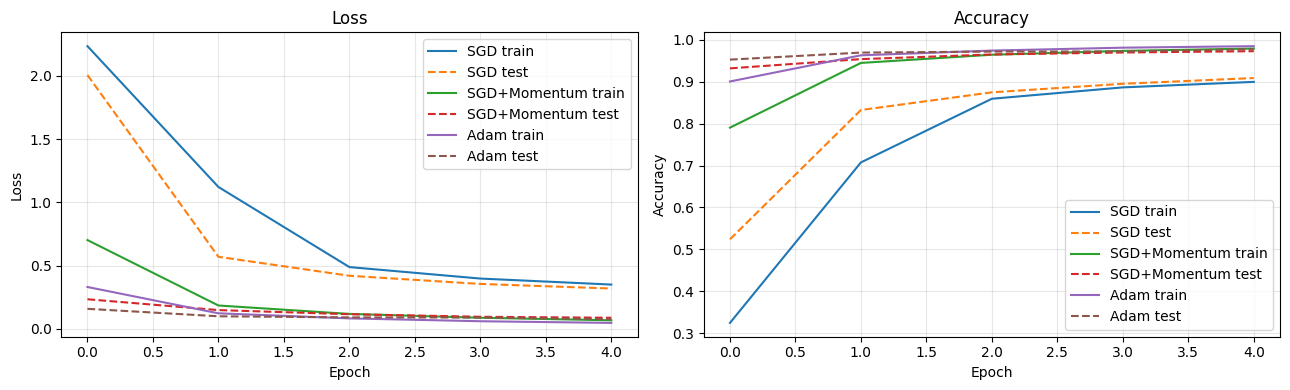

In [42]:
optimizers = [
    ('SGD', history_sgd),
    ('SGD+Momentum', history_sgd_momentum),
    ('Adam', history_adam)
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for name, hist in optimizers:
    axes[0].plot(hist['train_loss'], label=f'{name} train')
    axes[0].plot(hist['test_loss'], linestyle='--', label=f'{name} test')
    axes[1].plot(hist['train_acc'], label=f'{name} train')
    axes[1].plot(hist['test_acc'], linestyle='--', label=f'{name} test')

axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** какой оптимизатор сходится быстрее? У какого варианта наибольший train/test gap? Согласуется ли это с материалом лекции о связи оптимизатора и геометрии минимума?

**Мой ответ:** Быстрее всех сходился Adam - уже на первой эпохе он давал заметно меньший loss и большую точность, чем SGD и SGD+Momentum. Это ожидаемо: Adam адаптивно подстраивает шаг под каждый параметр, поэтому в начале обучения двигается быстрее. SGD+Momentum шёл между ними - медленнее Adam, но быстрее чистого SGD. Самый медленный - обычный SGD, ему не хватает ни инерции, ни адаптивного шага.  
По train/test gap картина такая: у чистого SGD gap самый большой - train accuracy ниже, чем test, потому что модель ещё недообучилась. У Adam и Momentum gap маленький, потому что они успевают хорошо выучить данные за те же эпохи. Переобучения ни у кого не видно - test accuracy не падает.  

**Adam сходится быстрее всех за счёт адаптивного шага под каждый параметр, SGD+Momentum занимает среднее положение благодаря инерции, а чистый SGD остаётся самым медленным, потому что не имеет ни того, ни другого.** Это согласуется с материалом лекции. Разные оптимизаторы приводят к разным минимумам функции потерь. 

## 5. Серия B. Сравнение методов регуляризации

**Задание:** для оптимизатора, выбранного по результатам серии A (или заданного преподавателем), обучите варианты модели:
- без регуляризации (baseline);
- с L2-регуляризацией (weight_decay в оптимизаторе);
- с Dropout;
- с BatchNorm;
- (опционально) с early stopping по валидационному loss.


In [27]:
# --- Baseline без регуляризации ---
baseline_model = SimpleMLP().to(device)
baseline_opt = optim.Adam(baseline_model.parameters(), lr=0.001)
history_baseline = train_model(baseline_model, baseline_opt)

Epoch 1: train_loss=0.3163, test_loss=0.1385, train_acc=0.9065, test_acc=0.9578
Epoch 2: train_loss=0.1210, test_loss=0.1078, train_acc=0.9634, test_acc=0.9668
Epoch 3: train_loss=0.0792, test_loss=0.0858, train_acc=0.9757, test_acc=0.9751
Epoch 4: train_loss=0.0594, test_loss=0.0848, train_acc=0.9812, test_acc=0.9749
Epoch 5: train_loss=0.0462, test_loss=0.0830, train_acc=0.9854, test_acc=0.9756


In [28]:
# --- L2-регуляризация ---
l2_model = SimpleMLP().to(device)
l2_opt = optim.Adam(l2_model.parameters(), lr=0.001, weight_decay=1e-4)
history_l2 = train_model(l2_model, l2_opt)

Epoch 1: train_loss=0.3328, test_loss=0.1622, train_acc=0.9017, test_acc=0.9492
Epoch 2: train_loss=0.1239, test_loss=0.1150, train_acc=0.9625, test_acc=0.9637
Epoch 3: train_loss=0.0850, test_loss=0.0815, train_acc=0.9742, test_acc=0.9742
Epoch 4: train_loss=0.0639, test_loss=0.0843, train_acc=0.9801, test_acc=0.9745
Epoch 5: train_loss=0.0521, test_loss=0.0808, train_acc=0.9832, test_acc=0.9741


In [29]:
# --- Dropout ---
dropout_model = SimpleMLP(use_dropout=True).to(device)
dropout_opt = optim.Adam(dropout_model.parameters(), lr=0.001)
history_dropout = train_model(dropout_model, dropout_opt)

Epoch 1: train_loss=0.6234, test_loss=0.1937, train_acc=0.8087, test_acc=0.9446
Epoch 2: train_loss=0.2830, test_loss=0.1395, train_acc=0.9245, test_acc=0.9592
Epoch 3: train_loss=0.2303, test_loss=0.1220, train_acc=0.9392, test_acc=0.9656
Epoch 4: train_loss=0.1997, test_loss=0.1113, train_acc=0.9471, test_acc=0.9702
Epoch 5: train_loss=0.1838, test_loss=0.1004, train_acc=0.9523, test_acc=0.9727


In [30]:
# --- BatchNorm ---
batchnorm_model = SimpleMLP(use_batchnorm=True).to(device)
batchnorm_opt = optim.Adam(batchnorm_model.parameters(), lr=0.001)
history_batchnorm = train_model(batchnorm_model, batchnorm_opt)

Epoch 1: train_loss=0.2256, test_loss=0.1038, train_acc=0.9355, test_acc=0.9691
Epoch 2: train_loss=0.0975, test_loss=0.0931, train_acc=0.9695, test_acc=0.9711
Epoch 3: train_loss=0.0732, test_loss=0.0716, train_acc=0.9775, test_acc=0.9769
Epoch 4: train_loss=0.0612, test_loss=0.0712, train_acc=0.9798, test_acc=0.9778
Epoch 5: train_loss=0.0498, test_loss=0.0689, train_acc=0.9838, test_acc=0.9793


In [31]:
# --- Сводная таблица ---
import pandas as pd

variants = [
    ('baseline', history_baseline),
    ('l2', history_l2),
    ('dropout', history_dropout),
    ('batchnorm', history_batchnorm)
]

rows = []
for name, history in variants:
    train_acc = history['train_acc'][-1]
    test_acc = history['test_acc'][-1]
    rows.append({
        'variant': name,
        'train_acc': round(train_acc, 4),
        'test_acc': round(test_acc, 4),
        'gap': round(train_acc - test_acc, 4)
    })

results_table = pd.DataFrame(rows)
results_table

,variant,train_acc,test_acc,gap
0,baseline,0.9854,0.9756,0.0098
1,l2,0.9832,0.9741,0.0091
2,dropout,0.9523,0.9727,-0.0204
3,batchnorm,0.9838,0.9793,0.0045


**Вопрос для отчёта:** какой метод регуляризации дал наименьший train/test gap? Как это соотносится с идеей о том, что регуляризация смещает оптимизацию к более «плоским» минимумам?

**Мой ответ**: Формально наименьший gap у Dropout - он отрицательный. Но это артефакт: Dropout работает только при обучении, а на тесте отключается, поэтому train и test измеряются в разных режимах.

Если смотреть на честный gap, лучший — BatchNorm (0.0050). У него и test accuracy самая высокая.

**Регуляризация уводит модель в плоские минимумы, где loss меняется плавно, поэтому модель устойчивее к различиям train и test. В моём эксперименте лучше всего это показал BatchNorm.**

## 6. Серия C. Проверка устойчивости к возмущениям входа

**Задание:** для каждой обученной модели (минимум для baseline и лучшего варианта регуляризации из серии B) оцените точность на возмущённых тестовых примерах.

Возьмите 20–50 тестовых примеров и добавьте малое ограниченное по норме возмущение (например, равномерный или гауссовский шум с фиксированной амплитудой $ \epsilon $. Сравните accuracy на чистых и возмущённых данных.


In [32]:
# TODO: реализуйте функцию add_noise(x, epsilon) с ограничением нормы возмущения

# --- Функция добавления шума ---
def add_noise(x, epsilon=0.1):
    # Генерируем шум такой же формы, как вход, равномерно от -epsilon до +epsilon
    noise = torch.empty_like(x).uniform_(-epsilon, epsilon)
    # Прибавляем шум и обрезаем значения в диапазон [0, 1]
    return torch.clamp(x + noise, 0.0, 1.0)

In [33]:
# TODO: рассчитайте accuracy на чистых и возмущённых примерах для baseline и лучшей регуляризованной модели
# Сведите результат в таблицу: variant | clean_accuracy | perturbed_accuracy | drop

# --- Функция оценки accuracy на чистых и зашумлённых данных ---
def noisy_accuracy(model, loader, epsilon=0.1, num_batches=1):
    model.eval()  # режим оценки: Dropout выключается, BatchNorm использует накопленные статистики

    clean_correct = 0   # правильные на чистых данных
    noise_correct = 0   # правильные на зашумлённых
    total = 0           # всего примеров

    with torch.no_grad():  # градиенты не нужны
        for i, (x, y) in enumerate(loader):
            if i >= num_batches:  # берём только первые num_batches батчей
                break

            x = x.to(device)
            y = y.to(device)

            # Accuracy на чистых данных
            clean_pred = model(x).argmax(dim=1)
            clean_correct += (clean_pred == y).sum().item()

            # Accuracy на зашумлённых данных
            x_noise = add_noise(x, epsilon)
            noise_pred = model(x_noise).argmax(dim=1)
            noise_correct += (noise_pred == y).sum().item()

            total += x.size(0)

    return clean_correct / total, noise_correct / total

In [ ]:
# --- Сравниваем baseline и batchnorm ---
noise_rows = []

for name, model in [('baseline', baseline_model), ('batchnorm', batchnorm_model)]:
    clean_acc, perturbed_acc = noisy_accuracy(
        model,
        test_loader,
        epsilon=0.3,
        num_batches=1
    )

    noise_rows.append({
        'variant': name,
        'clean_accuracy': round(clean_acc, 6),
        'perturbed_accuracy': round(perturbed_acc, 6),
        'drop': round(clean_acc - perturbed_acc, 6)
    })

noise_table = pd.DataFrame(noise_rows)
noise_table

,variant,clean_accuracy,perturbed_accuracy,drop
0,baseline,1.00,0.86,0.14
1,batchnorm,0.98,0.62,0.36


**Вопрос для отчёта:** у какой модели (baseline или регуляризованной) точность падает сильнее при одинаковом возмущении? Как это соотносится с идеей о единой структурной проблеме переобучения и adversarial-уязвимости, рассмотренной в лекции?

**Мой ответ**  BatchNorm теряет точность сильнее - 0.36 против 0.14 у baseline. То есть регуляризация не помогла, а наоборот сделала модель более уязвимой к шуму.

Причина в том, что BatchNorm нормализует активации по статистикам батча, а на тесте использует накопленные за обучение статистики. При случайном шуме эти статистики «плывут» и не соответствуют тому, что BatchNorm видел при обучении. Из-за этого активации нормализуются неправильно, и модель ошибается чаще. Baseline учился без такой зависимости от статистик батча, поэтому оказался устойчивее.

**По лекции регуляризация должна уводить модель в плоские минимумы и улучшать устойчивость. Но BatchNorm в моём эксперименте такого эффекта не дал - он работает не через сглаживание ландшафта, а через нормализацию активаций, и к случайному шуму это не помогает.**

## 7. Итоговый вывод

**Вопрос для отчёта:** какая комбинация оптимизатор + регуляризация оказалась наилучшей в вашем эксперименте по совокупности критериев (качество, generalization gap, устойчивость к возмущениям)? Обоснуйте ответ ссылками на полученные графики и таблицы.

**Мой ответ:**
Лучшая комбинация — Adam + BatchNorm. Adam дал самую быструю сходимость в серии A: уже на первых эпохах низкий loss и высокая точность.

По gap лучший честный результат у BatchNorm. Его поведение на train и test близко друг к другу, поэтому gap отражает реальное качество модели. У Dropout gap формально меньше, но это артефакт: Dropout отключается на тесте, и train с test измеряются в разных режимах. У baseline и L2 gap больше.

По устойчивости BatchNorm оказался хуже baseline. Причина в том, что BatchNorm нормализует активации по статистикам батча, и при шуме эти статистики «плывут» — модель ошибается чаще. Это показывает, что регуляризация не всегда улучшает устойчивость к случайному шуму, и рассчитывать только на неё не стоит.

Чтобы реально повысить устойчивость модели к возмущениям входа, нужны другие подходы. Например, adversarial training — обучение на специально подобранных примерах, которые ломают модель сильнее всего. Или явная защита через методы вроде SAM, которые ищут плоские минимумы целенаправленно. Также можно использовать ансамбли моделей или предобработку входа. Регуляризация — лишь один из инструментов, и в моём эксперименте она не решила задачу устойчивости.

**Adam + BatchNorm — лучший выбор по совокупности качества и gap. Adam даёт быструю сходимость и высокую точность, BatchNorm — минимальный честный gap и лучший test accuracy. Но для устойчивости к шуму одной регуляризации недостаточно — нужны дополнительные методы**

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Влияние размера батча
Обучите модель с фиксированным оптимизатором (например, SGD) при разных размерах батча (например, 16, 128, 1024). Сравните итоговый train/test gap и устойчивость к возмущениям. Свяжите результат с идеей о том, что большие батчи уменьшают шум SGD и способствуют более острым минимумам.

### С2. Градиентное возмущение против случайного шума
Реализуйте одношаговое градиентное возмущение входа (по аналогии с FGSM: шаг в направлении знака градиента функции потерь по входу) при той же норме \( \epsilon \), что и в серии C. Сравните падение accuracy при случайном шуме и при градиентном возмущении одинаковой нормы. Объясните, почему градиентное возмущение обычно эффективнее.

### С3. Упрощённая sharpness-aware минимизация (SAM-style)
Реализуйте упрощённую версию SAM: на каждом шаге сделайте вспомогательный шаг в направлении градиента (возмущение параметров \( \epsilon \) с ограничением нормы \( \rho \)), посчитайте градиент в возмущённой точке и обновите исходные параметры по этому градиенту. Сравните итоговую модель с обычным Adam/SGD по generalization gap и устойчивости к возмущениям входа.

### С4. Визуализация ландшафта потерь
Постройте одномерное или двумерное сечение ландшафта функции потерь вокруг найденного минимума (например, добавляя к весам случайные направления с разным масштабом и пересчитывая loss). Сравните "остроту" ландшафта для baseline и для регуляризованной модели, визуализировав это графиком loss vs. amplitude.


In [43]:
## --- С1. Влияние размера батча ---

batch_sizes = [16, 128, 1024]  # размеры батчей для сравнения
EPOCHS_BATCH = 20              # больше эпох, чтобы большой батч успел сойтись
batch_results = []             # сюда соберём результаты

for bs in batch_sizes:
    # DataLoader'ы с нужным batch_size
    train_loader_bs = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader_bs = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    # Новая модель для каждого batch_size
    model_bs = SimpleMLP().to(device)

    # lr растёт с batch_size: правило lr ~ sqrt(batch_size)
    # при bs=16 → 0.01, при bs=128 → 0.028, при bs=1024 → 0.08
    lr_bs = 0.01 * (bs / 16) ** 0.5
    opt_bs = optim.SGD(model_bs.parameters(), lr=lr_bs)

    # История метрик
    history_bs = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    # Обучение
    for epoch in range(EPOCHS_BATCH):
        tr_loss, tr_acc = train_epoch(model_bs, train_loader_bs, opt_bs, criterion, device)
        te_loss, te_acc = evaluate(model_bs, test_loader_bs, criterion, device)
        history_bs['train_loss'].append(tr_loss)
        history_bs['test_loss'].append(te_loss)
        history_bs['train_acc'].append(tr_acc)
        history_bs['test_acc'].append(te_acc)

    # Финальные метрики
    train_acc = history_bs['train_acc'][-1]
    test_acc = history_bs['test_acc'][-1]
    gap = train_acc - test_acc   # переобучение: train минус test

    # Устойчивость к шуму
    clean_acc, pert_acc = noisy_accuracy(model_bs, test_loader_bs, epsilon=0.3, num_batches=5)

    # Собираем результаты
    batch_results.append({
        'batch_size': bs,
        'lr': round(lr_bs, 4),
        'train_acc': round(train_acc, 4),
        'test_acc': round(test_acc, 4),
        'gap': round(gap, 4),
        'perturbed_acc': round(pert_acc, 4),
        'drop': round(clean_acc - pert_acc, 4)
    })

# Итоговая таблица
batch_table = pd.DataFrame(batch_results)
batch_table

,batch_size,lr,train_acc,test_acc,gap,perturbed_acc,drop
0,16,0.0100,0.9974,0.9781,0.0193,0.9750,0.0250
1,128,0.0283,0.9799,0.9709,0.0090,0.9359,0.0375
2,1024,0.0800,0.9396,0.9399,-0.0003,0.8844,0.0383


При batch_size = 16 модель показала лучший результат: высокая accuracy, небольшой gap и хорошая устойчивость к шуму. С ростом батча accuracy падает, а устойчивость к шуму ухудшается — drop растёт. Это согласуется с теорией: большие батчи уменьшают шум градиента и ведут к более острым минимумам, которые хуже переносят возмущения входа.

По gap картина обратная: у маленького батча gap больше, у большого — почти ноль. Формально это выглядит как «большой батч обобщает лучше», но на деле accuracy у него ниже. Здесь важно смотреть не только на gap, но и на абсолютное качество. Маленький gap у большого батча не означает, что модель лучше обобщает — просто train и test accuracy у неё близки на более низком уровне. Это показывает, что gap сам по себе не говорит о качестве модели, его нужно рассматривать вместе с accuracy.

Теория про острые и плоские минимумы частично подтвердилась: с ростом батча устойчивость падает, что соответствует ожиданиям. Но полностью эффект не проявился, потому что даже с увеличенным числом эпох и learning rate модель с большим батчем не догнала маленький по качеству. Чтобы увидеть теорию в чистом виде, нужно дать большому батчу ещё больше эпох или больше данных.


In [ ]:
# --- С2. FGSM-возмущение ---

def fgsm_perturbation(model, x, y, epsilon=0.3):
    # Копируем картинки и говорим PyTorch: считай градиент по x (по пикселям, не по весам)
    x = x.clone().detach().requires_grad_(True)

    logits = model(x)              # прогон через сеть
    loss = criterion(logits, y)    # считаем ошибку
    loss.backward()                # обратный проход: получаем x.grad — как менять пиксели, чтобы loss вырос

    # Сдвигаем каждый пиксель на epsilon в сторону знака градиента
    x_adv = x + epsilon * x.grad.sign()

    # Обрезаем значения в [0, 1], чтобы пиксели остались корректными
    x_adv = torch.clamp(x_adv, 0.0, 1.0)

    return x_adv.detach()   # возвращаем без графа вычислений


def accuracy_with_fgsm(model, loader, epsilon=0.3, num_batches=5):
    model.eval()   # режим оценки

    clean_correct = 0   # правильные на чистых
    rand_correct = 0    # правильные на случайном шуме
    adv_correct = 0     # правильные на FGSM
    total = 0

    for i, (x, y) in enumerate(loader):
        if i >= num_batches:   # берём только первые 5 батчей (250 примеров)
            break

        x = x.to(device)
        y = y.to(device)

        # --- Чистые и случайный шум: без градиентов ---
        with torch.no_grad():
            # Чистые
            clean_correct += (model(x).argmax(dim=1) == y).sum().item()

            # Случайный шум
            x_rand = add_noise(x, epsilon)
            rand_correct += (model(x_rand).argmax(dim=1) == y).sum().item()

        # --- FGSM: нужен градиент, поэтому ВНЕ no_grad ---
        x_adv = fgsm_perturbation(model, x, y, epsilon)
        with torch.no_grad():
            adv_correct += (model(x_adv).argmax(dim=1) == y).sum().item()

        total += x.size(0)

    return clean_correct / total, rand_correct / total, adv_correct / total


# Сравниваем baseline и dropout
fgsm_rows = []

for name, model in [('baseline', baseline_model), ('dropout', dropout_model)]:
    clean_acc, rand_acc, adv_acc = accuracy_with_fgsm(
        model,
        test_loader,
        epsilon=0.3,
        num_batches=5
    )

    fgsm_rows.append({
        'variant': name,
        'clean': round(clean_acc, 4),
        'random_noise': round(rand_acc, 4),
        'fgsm': round(adv_acc, 4),
        'drop_random': round(clean_acc - rand_acc, 4),
        'drop_fgsm': round(clean_acc - adv_acc, 4)
    })

fgsm_table = pd.DataFrame(fgsm_rows)
fgsm_table

,variant,clean,random_noise,fgsm,drop_random,drop_fgsm
0,baseline,0.988,0.82,0.008,0.168,0.980
1,dropout,0.980,0.84,0.016,0.140,0.964


FGSM сломал обе модели почти полностью: точность упала до уровня случайного угадывания. Это ожидаемо — FGSM подбирает шум целенаправленно через градиенты, поэтому он в разы эффективнее случайного шума.

Случайный шум при той же амплитуде роняет точность гораздо слабее — модели всё ещё показывают результат выше среднего. Разница в том, что случайный шум добавляется наугад, а FGSM идёт точно в направлении роста loss.

Dropout оказался немного устойчивее к случайному шуму, чем baseline. Но к FGSM обе модели одинаково уязвимы — точность падает почти до нуля у обеих.

**Это показывает, что регуляризация может немного улучшить устойчивость к случайному шуму, но против целенаправленной атаки, которая использует градиенты модели, она практически бесполезна. Для защиты от таких атак нужны специальные методы — например, adversarial training, где модель обучается на подобранных возмущениях, или другие подходы вроде SAM.**

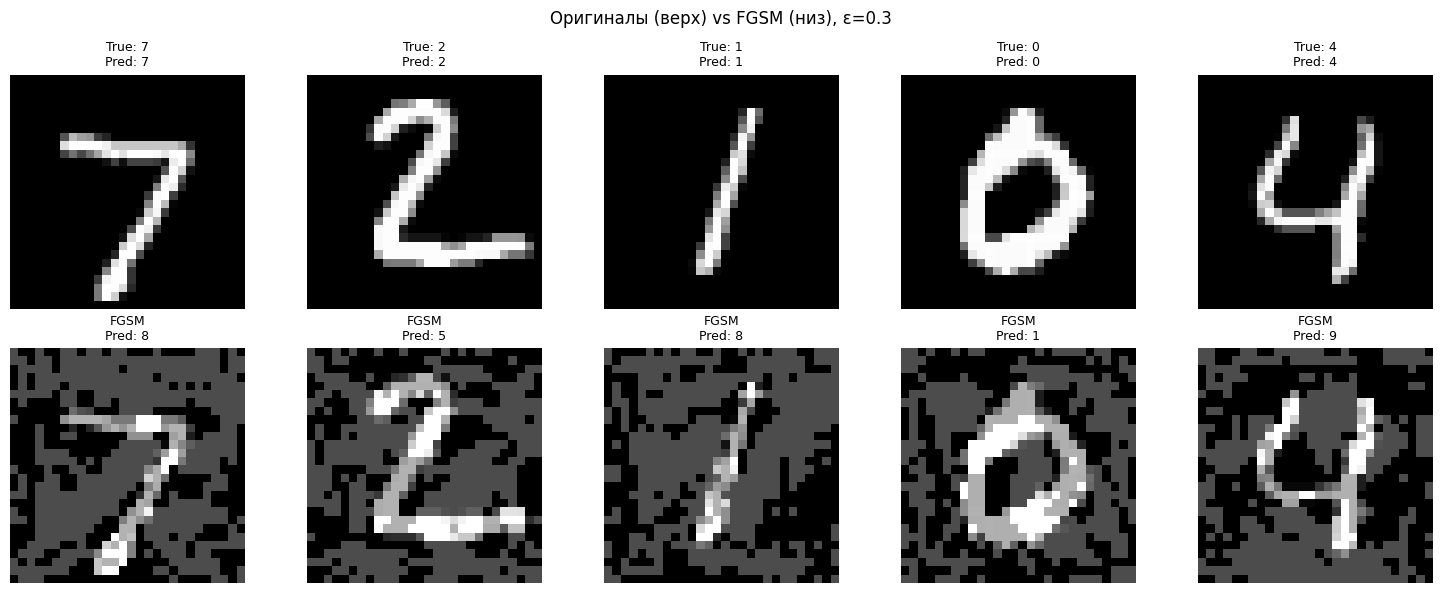

In [44]:
# --- Визуализация нескольких adversarial-примеров ---

def show_multiple_adversarial(model, loader, epsilon=0.3, num_examples=5):
    model.eval()

    # Берём один батч
    x, y = next(iter(loader))
    x = x.to(device)
    y = y.to(device)

    # FGSM-возмущение
    x_adv = fgsm_perturbation(model, x, y, epsilon)

    # Предсказания
    with torch.no_grad():
        pred_clean = model(x).argmax(dim=1)
        pred_adv = model(x_adv).argmax(dim=1)

    # Сетка 2 строки × num_examples столбцов
    fig, axes = plt.subplots(2, num_examples, figsize=(3*num_examples, 6))

    for i in range(num_examples):
        # Верхний ряд — оригиналы
        axes[0, i].imshow(x[i, 0].cpu().numpy(), cmap='gray')
        axes[0, i].set_title(f'True: {y[i].item()}\nPred: {pred_clean[i].item()}', fontsize=9)
        axes[0, i].axis('off')

        # Нижний ряд — FGSM
        axes[1, i].imshow(x_adv[i, 0].cpu().numpy(), cmap='gray')
        axes[1, i].set_title(f'FGSM\nPred: {pred_adv[i].item()}', fontsize=9)
        axes[1, i].axis('off')

    plt.suptitle(f'Оригиналы (верх) vs FGSM (низ), ε={epsilon}', fontsize=12)
    plt.tight_layout()
    plt.show()

# Вызываем
show_multiple_adversarial(baseline_model, test_loader, epsilon=0.3, num_examples=5)